In [1]:
import pickle as pkl
import pandas as pd
from load_performances import Performance_Loader
import numpy as np
from matrix_calculation_tools import *


In [2]:
from sentence_splitter import SentenceSplitter
splitter = SentenceSplitter(language='en')

In [3]:
material_path = '../../rag_utility'
_ret = 'mt5'

f = open(f'{material_path}/doc_dicts/msmarco_passage_dict.pkl', 'rb')
doc_dict = pkl.load(f)
f.close()

dl_19_res = pd.read_csv(f'{material_path}/res/{_ret}_dl_19.csv')
dl_20_res = pd.read_csv(f'{material_path}/res/{_ret}_dl_20.csv')
dl_res = pd.concat([dl_19_res, dl_20_res])

doc_length_dict = {}
for qid in dl_res.qid.unique():

    length_list = []
    doc_texts = dl_res[dl_res.qid == qid].docno.apply(lambda x: doc_dict[str(x)]).values
    sentences = []
    for doc_text in doc_texts:
        length_list.append(len(splitter.split(doc_text)))
    doc_length_dict.update({qid: length_list})

In [4]:
_k = 10

pfm_loader = Performance_Loader()

# kshot_pfms = pfm_loader.load_itg_performances(_ret, _k)
kshot_pfms = pfm_loader.load_sep_performances(_ret, _k)
zeroshot_pfms = pfm_loader.load_0shot_performances()

utility_dict = {}
for qid in set(kshot_pfms.keys()).intersection(set(zeroshot_pfms.keys())):
    utility_dict.update({qid: (kshot_pfms[qid] - zeroshot_pfms[qid])/zeroshot_pfms[qid]})

In [5]:
# load coherence matrix
f = open(f'../coherence_res/dl_15_{_ret}.pkl', 'rb') # currently we calculates the sentence-pair coherence to 15
matrix = pkl.load(f)
f.close()

In [6]:
def cal_coherence(_window=0, _step=1): # 0 for document average, no overlaping
    _coh_dict = {}
    
    for qid, mtx in matrix.items():
        
        stc_num_in_top_k = np.sum(doc_length_dict[qid][:_k])
        cut_mtx = np.matrix(mtx)[:stc_num_in_top_k][:stc_num_in_top_k]
    
        _sub_cohs = [] # coherence in a sub-piece of context

        if(_window == 0):
            ## document average
            # print(doc_length_dict[qid])
            _start = 0
            for _d_start in doc_length_dict[qid][:_k]:
                if(_d_start > 1):
                    submat = cut_mtx[_start:_start+_d_start,_start:_start+_d_start]
                    _sub_cohs.append(cal_column_avg_upper_triangle(submat))
                _start += _d_start

        else:
            ## fixed length average            
            _real_window = min(stc_num_in_top_k, _window)
            if(_real_window == 1):
                continue
            for _start in range(0, stc_num_in_top_k-_real_window+1, _step):
                submat = cut_mtx[_start:_start+_real_window,_start:_start+_real_window]
                _sub_cohs.append(cal_column_avg_upper_triangle(submat))
        
        if(len(_sub_cohs) > 0):
            # _coh_dict.update({str(qid): _sub_cohs[-1]})
            # print(qid, _sub_cohs)
            _coh_dict.update({str(qid): np.mean(_sub_cohs)})
            # print(qid, doc_length_dict[qid][:_k], np.mean(_sub_cohs))
    return _coh_dict

should be estimated:  96 ; number of estimations:  97 ; really estimated:  96
r: 0.3960166730448502
tau: 0.162719298245614


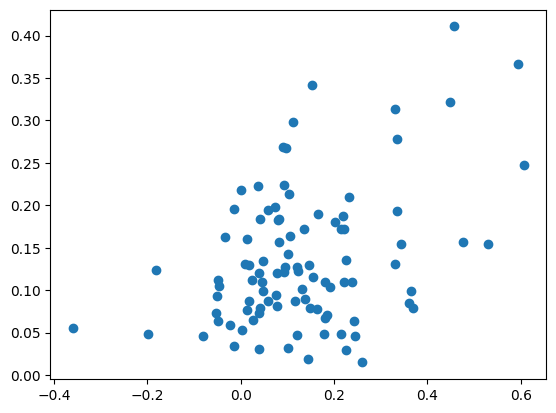

{'r': PearsonRResult(statistic=0.3960166730448502, pvalue=6.499633718753291e-05),
 'tau': SignificanceResult(statistic=0.162719298245614, pvalue=0.018843982626781136),
 'rho': SignificanceResult(statistic=0.23528214867064567, pvalue=0.02102237773325125)}

In [10]:
from correlation_tool import *

coh_dict = cal_coherence(_window=5, _step=4)
# print(coh_dict)
correlator(utility_dict, coh_dict)
# correlator(kshot_pfms, coh_dict) # correlation with the kshot performance
